Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7fb7c7a95120>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7fb7c7dcb1a0>
  [2] Plot1_ttbar -> Plotting builder=<function plotting_1 at 0x7fb7c70dd580>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot1_ttbar
Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7fb7c7a95120>
Extracted from cache: cache/Fileset/29957b32720a5e4591795a133244214b8a0e932d745a6243e892a113e96f716f
  -> materialized at cache/Fileset/29957b32720a5e4591795a133244214b8a0e932d745a6243e892a113e96f716f
Executing step 'Analysis_ttbar' of type 'Analysis' with the user code <function run_analysis at 0x7fb7c7dcb1a0>
Extracted from cache: cache/Chunking/f93ec2f8d112713bb7629aecd918fb007843ec6f24226625b8fb882517db3407

Split strategy applied, starting independent processing of 43 fileset subsets...

chunk_fraction=0.3: processing 13 of 43 chunks
------------------

Output()

Output()


execution took 18.96 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_15.json


Output()

...

Output()


execution took 17.66 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json


Output()

Output()


execution took 13.72 seconds
Successfully processed!
  -> materialized at cache/Analysis/34e0d81319f106fd9e572a76bc211dcb0806548b2823b31118c38fc14ef10743
Executing step 'Plot1_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7fb7c70dd580>
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at cache/Plotting/6df6139816d4af889467f2b0a1a91b0fe93731c525c0867bfe50c42a0325ebd6

=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  ✓  Analysis_ttbar                 Analysis             13/13 chunks OK
  ✓  Plot1_ttbar                    Plotting



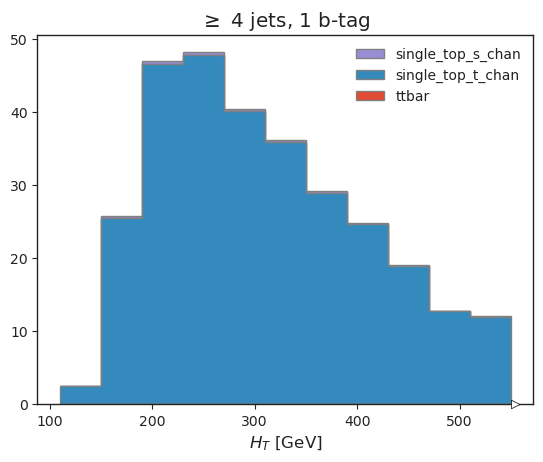

In [3]:
from workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, render
from ttbar_analysis import get_fileset, run_analysis, plotting_1

step_fileset = Step(
							        name="Fileset_ttbar",
							        step_type = Fileset,
							        builder = get_fileset,
							    )
step_analysis = Step(
						        name="Analysis_ttbar",
						        step_type = Analysis,
						        builder = run_analysis,
						    )

step_plot1 = Step(
						        name="Plot1_ttbar",
						        step_type = Plotting,
						        builder = plotting_1,
						    )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plot1, depends_on=[step_analysis])
config = RunConfig(percentage=10, strategy="by_dataset", cache_dir="cache", chunk_fraction=0.3)
result = render(workflow, config)